In [2]:
PHYLOGWAS_ROOT <- Sys.getenv("PHYLOGWAS_ROOT", unset = "/workdir/sh2246/p_phyloGWAS")

library(limma)
library(parallel)
library(jsonlite)
library(UpSetR)
library(ggplot2)

In [5]:
metadata = read.csv(file.path(PHYLOGWAS_ROOT, "data/DEG_study_metadata.csv"),header = T)

In [6]:
head(metadata)

,study,species,stress,tissue,sequence,who.s.in.charge,path.to.candidate.genes,CDS.fa
,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
1,Oren et al,Andropogon gerardii,cold,rhizome,Protein,Elad,output/candidateGenes/Ag_rhizome_DAPs.list,Ag.cds.fa.gz
2,Medina-Chávez et al. 2023,Brachypodium distachyon,waterlogging,shoots,RNA,Sheng-Kai,output/candidateGenes/Bdi_submergence_MedinaChávez_2023,Bdistachyon_314_v3.1.cds_primaryTranscriptOnly.fa.gz
3,Fang et al. 2022,Cynodon dactylon,drought,leaf,RNA,Sheng-Kai,output/candidateGenes/Cda_drought_Fang_2022,osa1_r7.gene_models.repr.cds.fa.gz
4,Liu et al. 2022,Cynodon dactylon,heat,leaf,RNA,Sheng-Kai,output/candidateGenes/Cda_heat_Liu_2022,Araport11_seq_20220914_representative_gene_model.fa.gz
5,Fang et al. 2022,Cynodon dactylon,waterlogging,leaf,RNA,Sheng-Kai,output/candidateGenes/Cda_submergence_Fang_2022,osa1_r7.gene_models.repr.cds.fa.gz
6,Miricescu et al. 2023,Hordeum vulgare,waterlogging,root,RNA,Sheng-Kai,output/candidateGenes/Hvu_waterlogging_Miricescu_2023,Hordeum_vulgare.MorexV3_pseudomolecules_assembly.cds.all.fa.gz


In [929]:
DEG_list = lapply(metadata[,7],function(x) read.table(file.path(PHYLOGWAS_ROOT,x),header = F)[,1])

In [930]:
sapply(DEG_list,length)

[1]   185  4447    59  4659   514  2865  8395 11267  2255  2754    83  8399
[13]  3437  1344   695  2147  7948  6911    54  1872  3148   394  4888  2575
[25]  1708   612 11218  2980  2605    60   669  1198  7827  1001  3747  2733
[37]  5988   116  9301  2427   594    35  6194  1826  2384

In [202]:
DEG_trsl_list = lapply(1:nrow(metadata),function(x) {
    if (metadata[x,8]=="") return(NA)
    else{
        tmp = read.delim(paste0(file.path(PHYLOGWAS_ROOT, "data/DEG_mappingFiles/OG_mapping_"),
                        gsub(".fa.gz","",metadata[x,8]),".txt"),header = F)
        candidate = DEG_list[[x]]
        idx = tmp[,1]%in%candidate|
            gsub("\\.[0-9]+$","",tmp[,1])%in%candidate|
            gsub("t","g",tmp[,1])%in%candidate|
            toupper(tmp[,1])%in%candidate|
            strsplit2(tmp[,1],split = "_")[,1]%in%candidate|
            gsub("Os","OS",gsub("t","G",strsplit2(tmp[,1],split = "-")[,1]))%in%candidate|
            gsub("t","g",strsplit2(tmp[,1],split = "-")[,1])%in%candidate|
            tmp[,1]%in%gsub('\\.v.\\.1$','',candidate)
        if (x==21) idx = strsplit2(tmp[,1],split = "_")[,2]%in%strsplit2(candidate,"_")[,2]
        return(unique(tmp[idx,2]))
    }

})

In [131]:
which(sapply(DEG_trsl_list,length)==0)

integer(0)

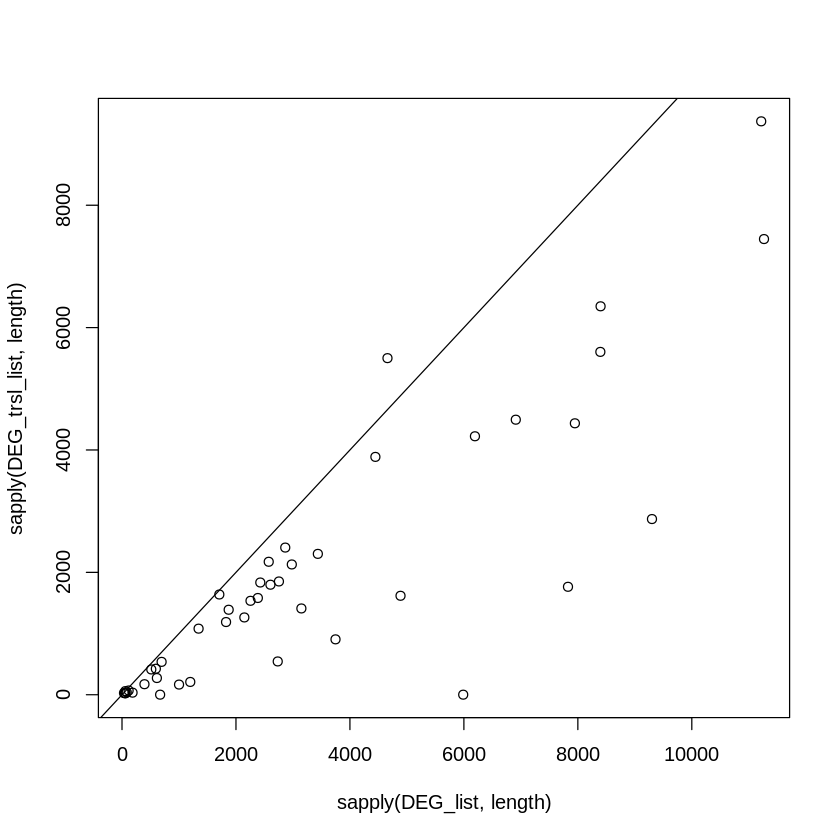

In [147]:
plot(sapply(DEG_list,length),sapply(DEG_trsl_list,length))
abline(a=0,b=1)

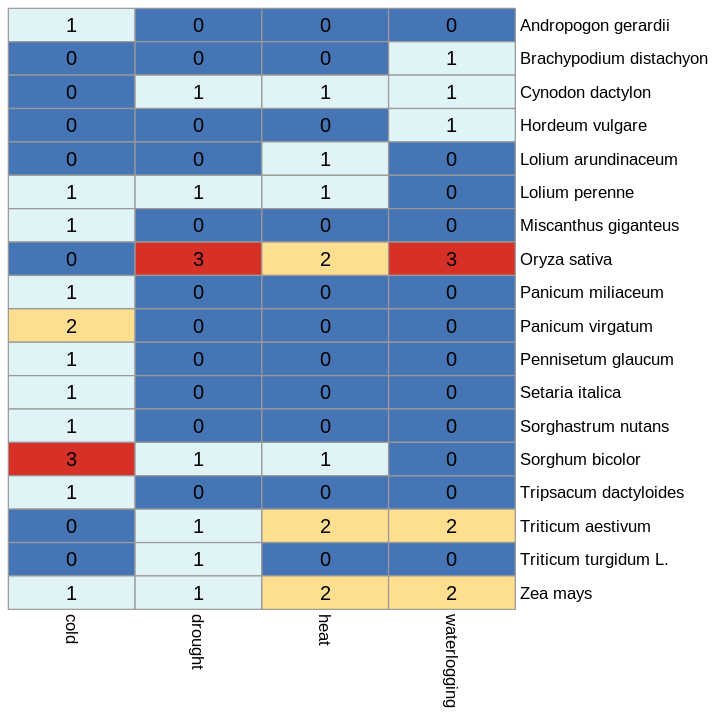

In [561]:
options(repr.plot.width=6, repr.plot.height=6)

pheatmap::pheatmap(table(metadata$species[metadata[,8]!=''],metadata$stress[metadata[,8]!='']),
                   cluster_rows = F,cluster_cols = F,legend = F,
                   number_format = "%.0f",
                   number_color = "black",
                   display_numbers = T,fontsize_number = 12)

In [244]:
summary(sapply(DEG_list,length))

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
     35     669    2427    3256    4659   11267 

In [258]:
cbind(sapply(DEG_list,length),sapply(DEG_trsl_list,length))
summary(sapply(DEG_trsl_list,length)/sapply(DEG_list,length))

output/candidateGenes/Ag_rhizome_DAPs.list,185,34
output/candidateGenes/Bdi_submergence_MedinaChávez_2023,4447,3887
output/candidateGenes/Cda_drought_Fang_2022,59,59
output/candidateGenes/Cda_heat_Liu_2022,4659,5501
output/candidateGenes/Cda_submergence_Fang_2022,514,413
output/candidateGenes/Hvu_waterlogging_Miricescu_2023,2865,2405
output/candidateGenes/Lar_heat_Alam_2018,8395,5603
output/candidateGenes/Lpe_cold_Pashapu_2024,11267,7447
output/candidateGenes/Lpe_drought_Sun_2020,2255,1535
output/candidateGenes/Lpe_heat_Sun_2020,2754,1851
output/candidateGenes/Mg_rhizome_DAPs.list,83,39


    Min.  1st Qu.   Median     Mean  3rd Qu.     Max. 
0.000167 0.436548 0.663171 0.584448 0.755804 1.180726 

Warning message:
“Removed 1 row containing missing values or values outside the scale range (`geom_bar()`).”


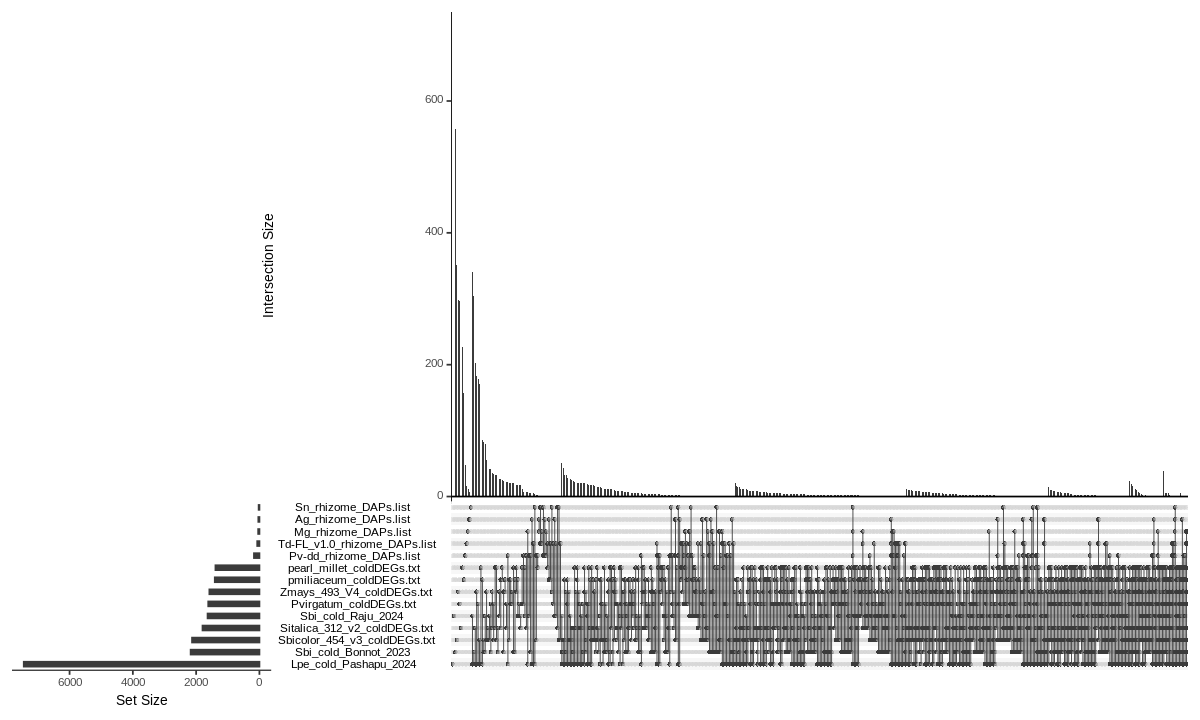

In [273]:
options(repr.plot.width=10, repr.plot.height=6)

names(DEG_trsl_list) = strsplit2(metadata[,7],"/")[,3]
upset(fromList(DEG_trsl_list[metadata[,3]%in%"cold"]),nsets = 14,nintersects = NA,line.size = 0.25,
      show.numbers = F,point.size = 1,mainbar.y.max = 700)

Warning message:
“Removed 1 row containing missing values or values outside the scale range (`geom_bar()`).”


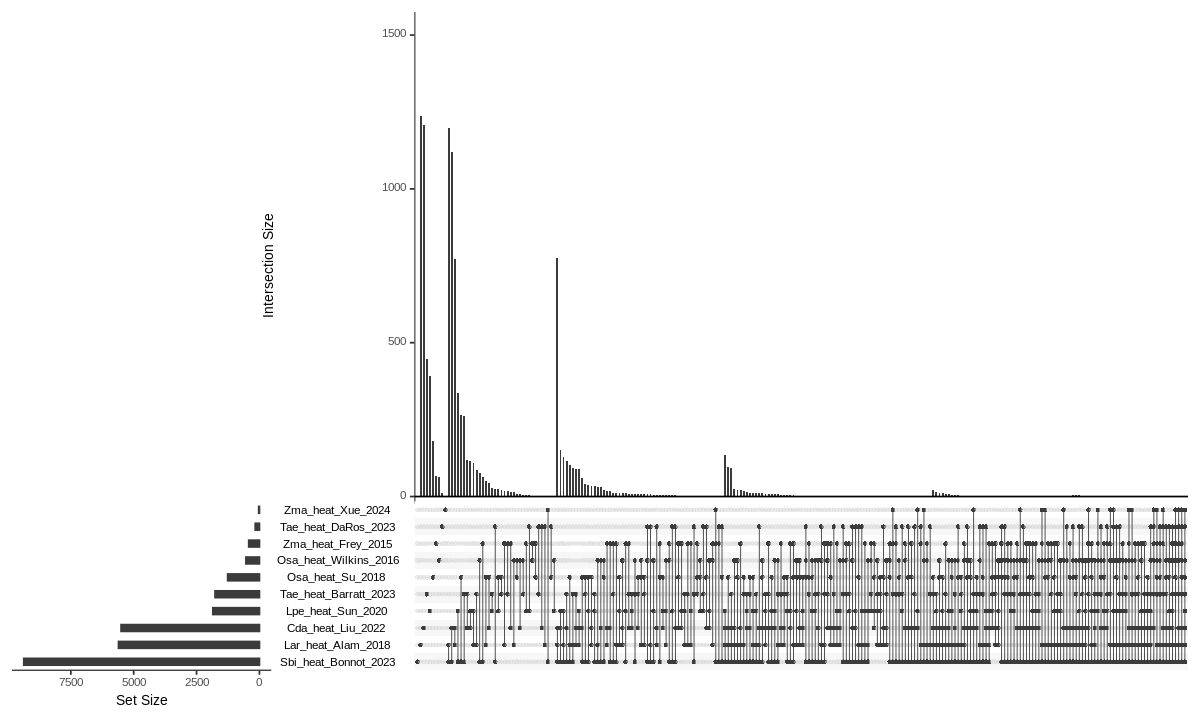

In [272]:
upset(fromList(DEG_trsl_list[metadata[,3]%in%"heat"]),nsets = 14,nintersects = NA,line.size = 0.25,
      show.numbers = F,point.size = 1,mainbar.y.max = 1500)

Warning message:
“Removed 1 row containing missing values or values outside the scale range (`geom_bar()`).”


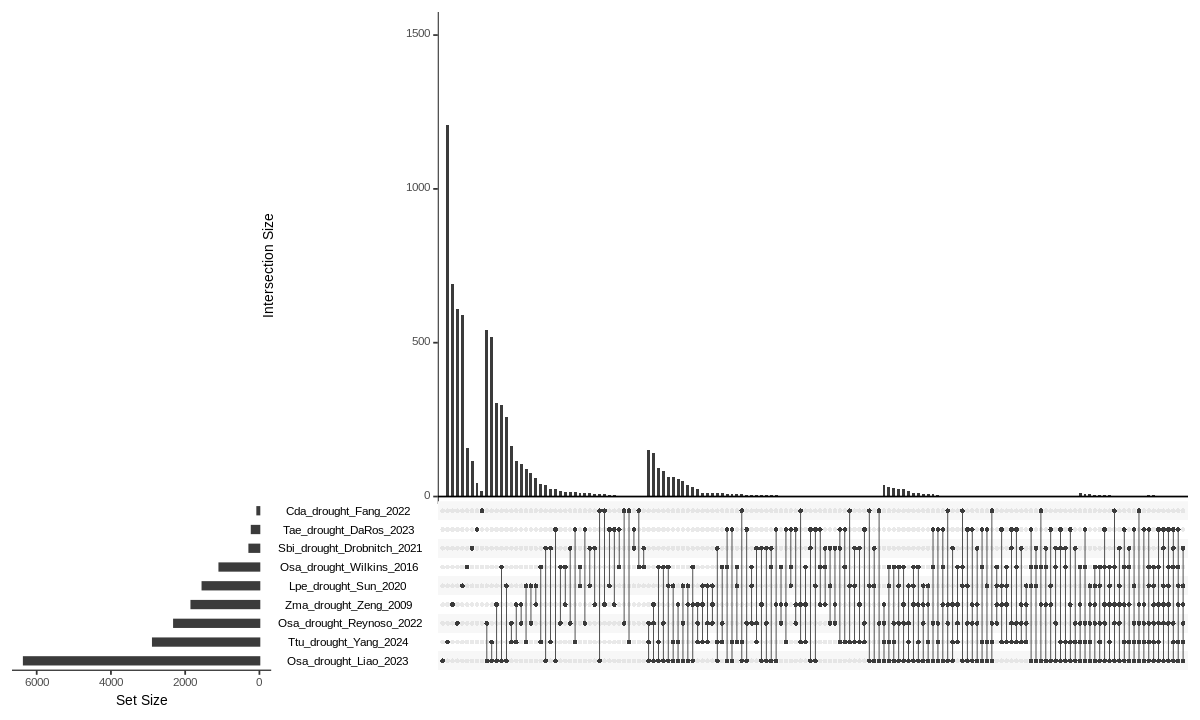

In [275]:
upset(fromList(DEG_trsl_list[metadata[,3]%in%"drought"]),nsets = 14,nintersects = NA,line.size = 0.25,
      show.numbers = F,point.size = 1,mainbar.y.max = 1500)

Warning message:
“Removed 1 row containing missing values or values outside the scale range (`geom_bar()`).”


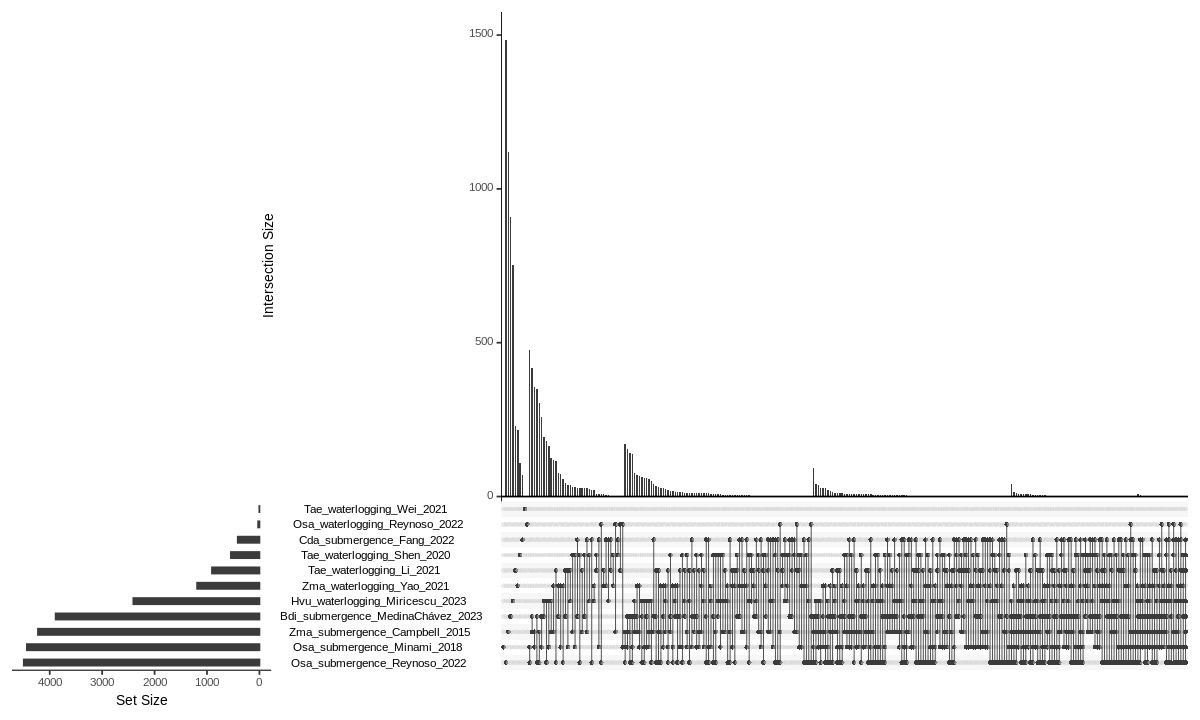

In [277]:
upset(fromList(DEG_trsl_list[metadata[,3]%in%"waterlogging"]),nsets = 14,nintersects = NA,line.size = 0.25,
      show.numbers = F,point.size = 1,mainbar.y.max = 1500)

In [429]:
table(metadata$stress)


        cold      drought         heat waterlogging 
          15            9           10           11 

In [ ]:
background = read.table(file.path(PHYLOGWAS_ROOT, "output/poaceaeHelixerOG_filtered_20250331.txt"))[,1]

In [693]:
set.seed(1234)
rSet1 = lapply(sapply(DEG_trsl_list[metadata[,3]%in%"cold"],length),function(x) sample(background,size = x,replace = F))
rSet2 = lapply(sapply(DEG_trsl_list[metadata[,3]%in%"heat"],length),function(x) sample(background,size = x,replace = F))
rSet3 = lapply(sapply(DEG_trsl_list[metadata[,3]%in%"drought"],length),function(x) sample(background,size = x,replace = F))
rSet4 = lapply(sapply(DEG_trsl_list[metadata[,3]%in%"waterlogging"],length),function(x) sample(background,size = x,replace = F))

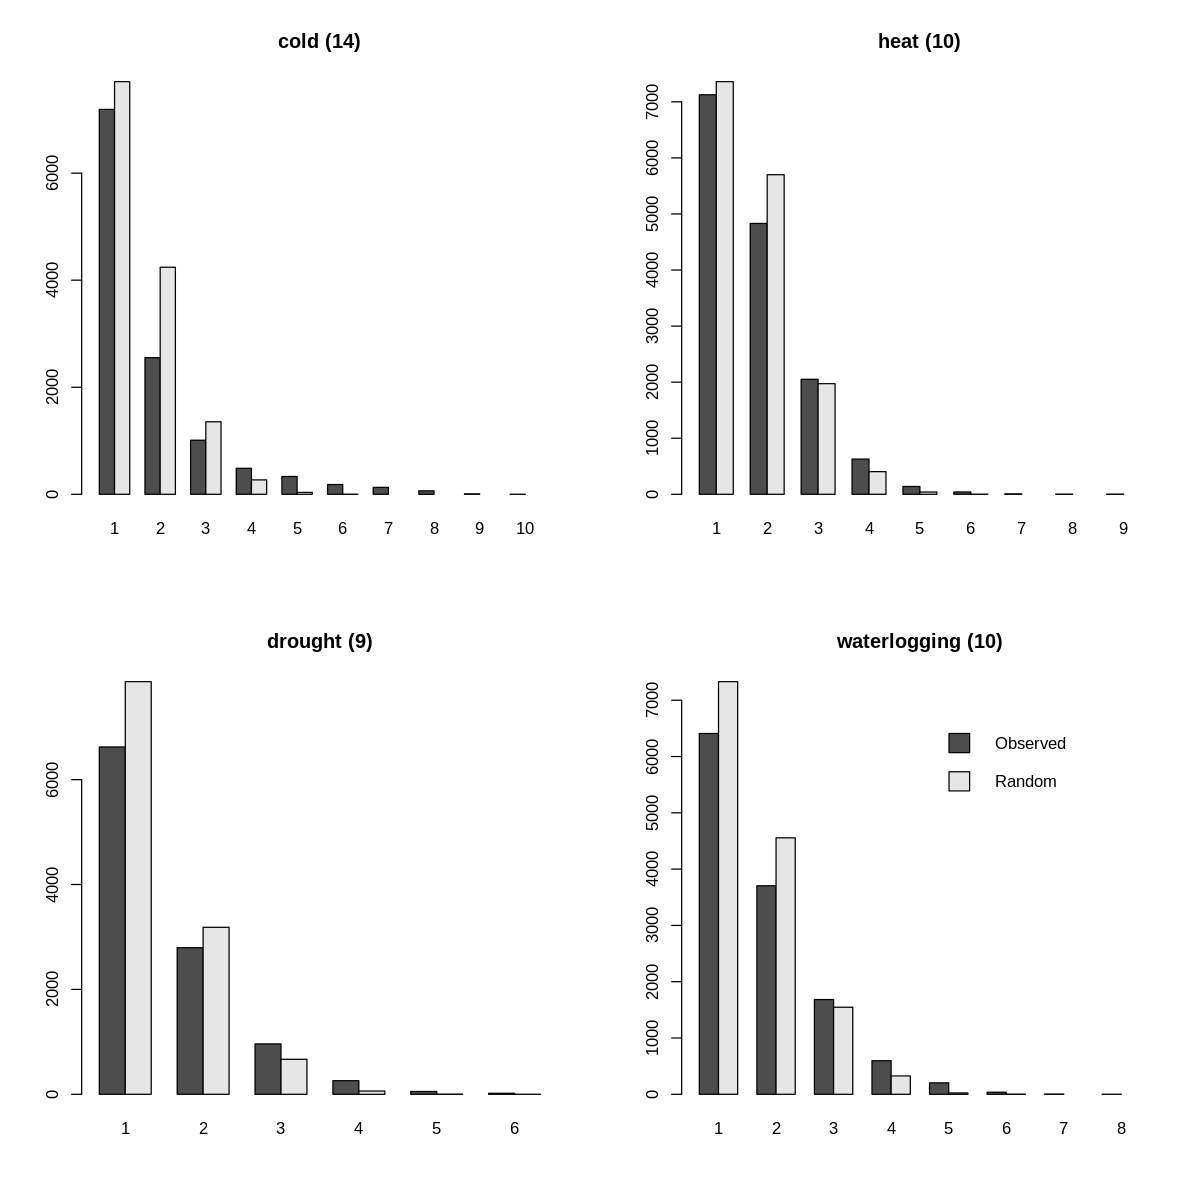

In [698]:
options(repr.plot.width=10, repr.plot.height=10)
par(mfrow = c(2,2))
barplot(rbind(table(table(coldList)),table(table(unlist(rSet1)))[names(table(table(coldList)))]),beside = T,main = "cold (14)")
barplot(rbind(table(table(heatList)),table(table(unlist(rSet2)))[names(table(table(heatList)))]),beside = T,main = "heat (10)")
barplot(rbind(table(table(droughtList)),table(table(unlist(rSet3)))[names(table(table(droughtList)))]),beside = T,main = "drought (9)")
barplot(rbind(table(table(waterList)),table(table(unlist(rSet4)))[names(table(table(waterList)))]),beside = T,
        args.legend = list(bty='n'),legend.text = c("Observed","Random"),main = "waterlogging (10)")

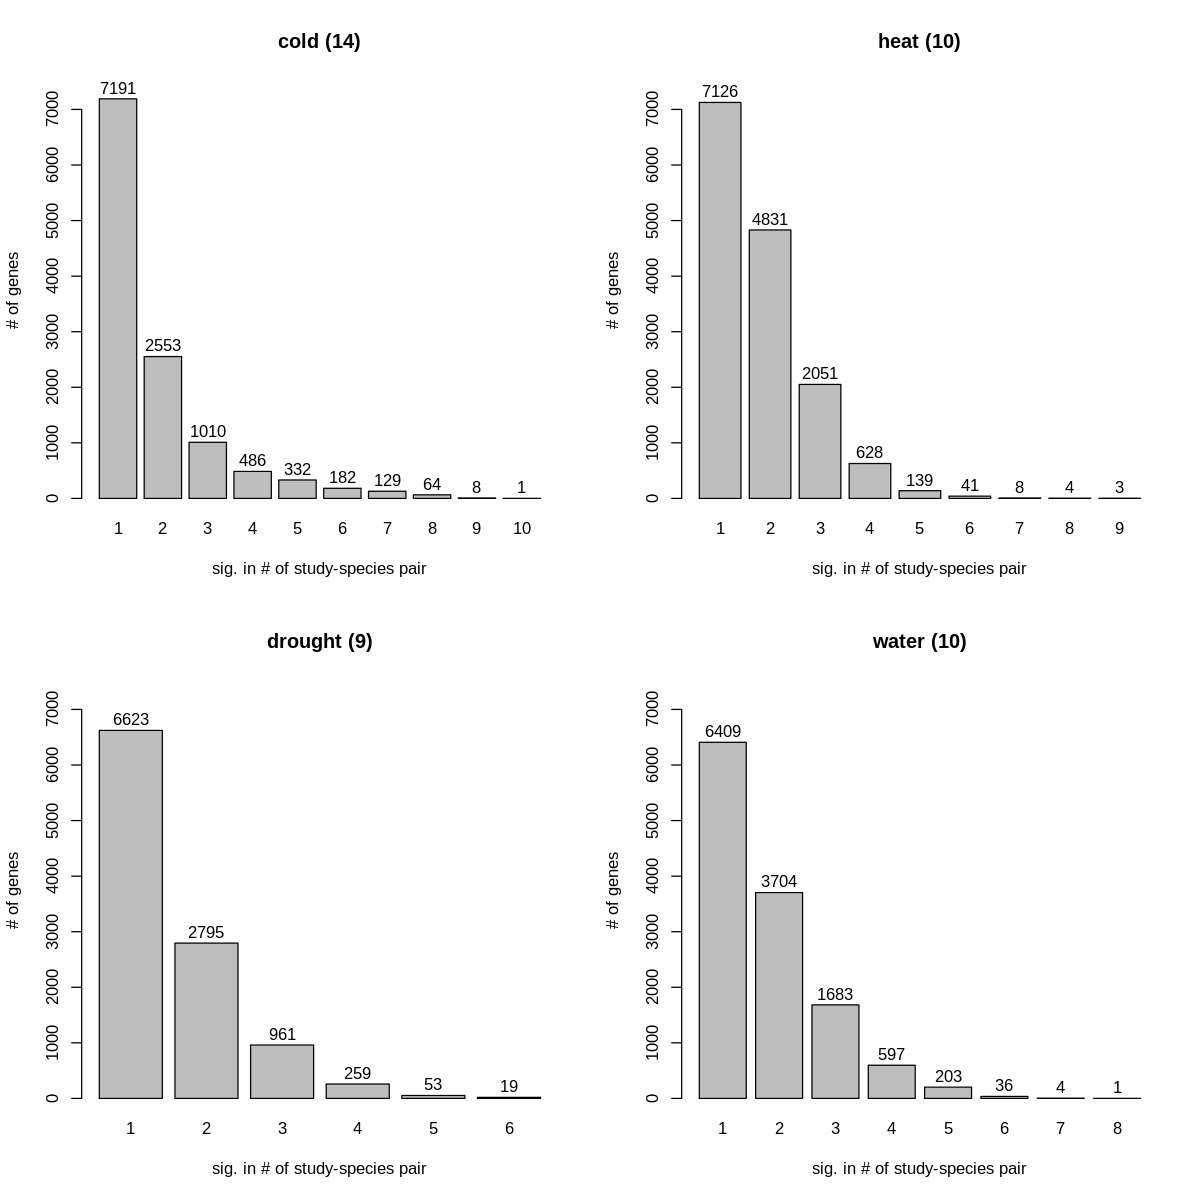

In [562]:
options(repr.plot.width=10, repr.plot.height=10)
par(mfrow = c(2,2))
bp = barplot(table(table(coldList)),xlab = "sig. in # of study-species pair",ylab = "# of genes",
             main = "cold (14)",ylim = c(0,7500))
text(bp,table(table(coldList))+200,table(table(coldList)))
bp = barplot(table(table(heatList)),xlab = "sig. in # of study-species pair",ylab = "# of genes",
             main = "heat (10)",ylim = c(0,7500))
text(bp,table(table(heatList))+200,table(table(heatList)))
bp = barplot(table(table(droughtList)),xlab = "sig. in # of study-species pair",ylab = "# of genes",
             main = "drought (9)",ylim = c(0,7500))
text(bp,table(table(droughtList))+200,table(table(droughtList)))
bp = barplot(table(table(waterList)),xlab = "sig. in # of study-species pair",ylab = "# of genes",
             main = "water (10)",ylim = c(0,7500))
text(bp,table(table(waterList))+200,table(table(waterList)))


In [7]:
sum(metadata[,3]%in%"cold")

[1] 15

In [8]:
coldList =unlist(DEG_trsl_list[metadata[,3]%in%"cold"])
coldResponsiveGenes = names(table(coldList))[which(table(coldList)>2)]

ERROR: Error in unlist(DEG_trsl_list[metadata[, 3] %in% "cold"]): object 'DEG_trsl_list' not found


In [714]:
heatList =unlist(DEG_trsl_list[metadata[,3]%in%"heat"])
heatResponsiveGenes = names(table(heatList))[which(table(heatList)>2)]

In [715]:
droughtList =unlist(DEG_trsl_list[metadata[,3]%in%"drought"])
droughtResponsiveGenes = names(table(droughtList))[which(table(droughtList)>2)]

In [716]:
waterList =unlist(DEG_trsl_list[metadata[,3]%in%"waterlogging"])
waterResponsiveGenes = names(table(waterList))[which(table(waterList)>2)]

In [717]:
length(coldResponsiveGenes)
length(heatResponsiveGenes)
length(droughtResponsiveGenes)
length(waterResponsiveGenes)

[1] 2212

[1] 2874

[1] 1292

[1] 2524

In [ ]:
envResponsiveGenes = list(coldResponsiveGenes,heatResponsiveGenes,droughtResponsiveGenes,waterResponsiveGenes)

names(envResponsiveGenes) = c("cold","heat","drought","waterlogging")

write_json(envResponsiveGenes, file.path(PHYLOGWAS_ROOT, "output/candidateGenes/consistentEnvResponsiveGenes.json"))

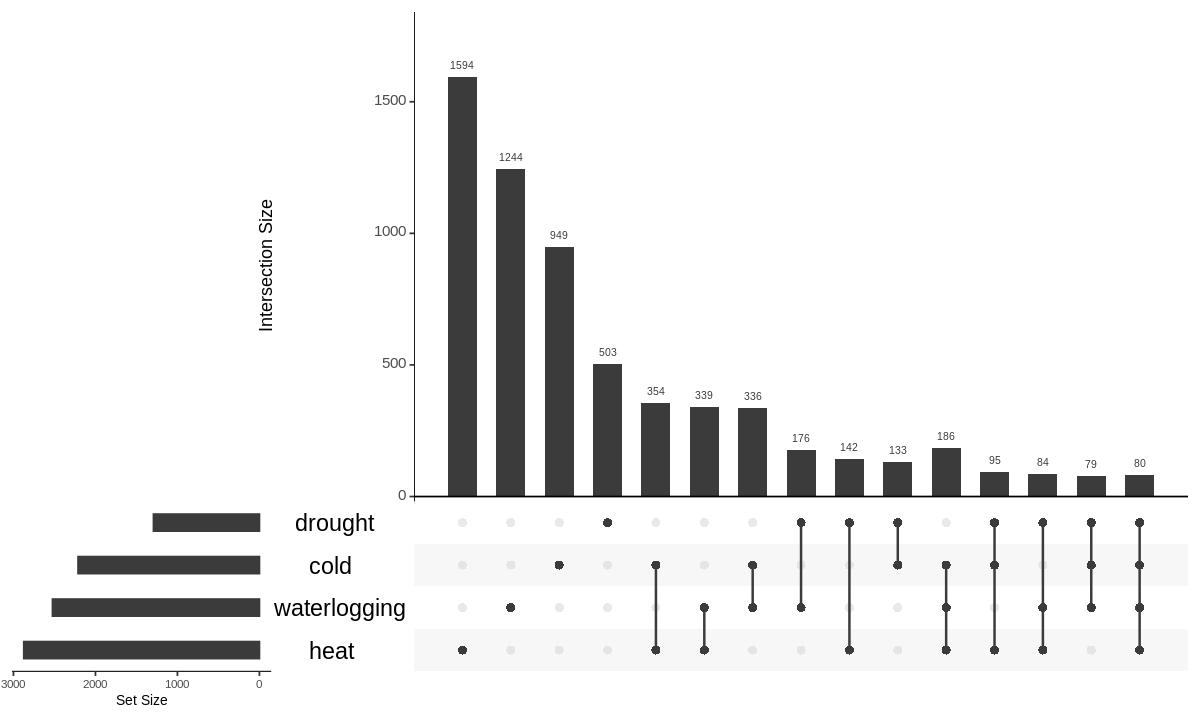

In [3]:
options(repr.plot.width=10, repr.plot.height=6)
upset(fromList(envResponsiveGenes),text.scale = c(1.3, 1.3, 1, 1, 2, 1))

In [5]:
sapply(envResponsiveGenes,function(x) any(x%in%"OG0018131"))

cold         heat      drought waterlogging 
       FALSE        FALSE        FALSE        FALSE